In [4]:
#without birad category WITHOUT BIRAD
# ----------------------------------------
# Step 1: Import Required Libraries
# ----------------------------------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------------------
# Step 2: Load the Dataset
# ----------------------------------------
data = pd.read_csv('details.csv')

# ----------------------------------------
# Step 3: Keep Only Cancer and Not Cancer Labels
# ----------------------------------------
data = data[data['Ground truth label'].isin(['Cancer', 'Not cancer'])]
data['target'] = data['Ground truth label'].map({'Cancer': 1, 'Not cancer': 0})

# ----------------------------------------
# Step 4: Drop Unnecessary or Leaky Columns
# ----------------------------------------
drop_cols = [
    'Sample Type ID', 'Sample ID', 'De-identified Patient ID',
    'Ground truth label', 'Clinical Indication',
    'ICD-11 Code (patient health condition)'
]
data.drop(columns=drop_cols, inplace=True, errors='ignore')

# ----------------------------------------
# Step 5: Handle Missing Values and Remove Duplicates
# ----------------------------------------
data = data.drop_duplicates()
data.ffill(inplace=True)  # forward-fill missing values safely

# ----------------------------------------
# Step 6: Encode Categorical Columns
# ----------------------------------------
for col in data.select_dtypes(include='object').columns:
    data[col] = LabelEncoder().fit_transform(data[col])

# ----------------------------------------
# Step 7: Split Features (X) and Target (y)
# ----------------------------------------
X = data.drop(columns=['target', 'BIRADS category'])
#X = data.drop(columns=['target'])
y = data['target']

# Optional: Remove BIRADS if you want more general model
# X = X.drop(columns=['BIRADS category'])

# ----------------------------------------
# Step 8: Train-Test Split (80/20)
# ----------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ----------------------------------------
# Step 9: Balance Classes Using SMOTE
# ----------------------------------------
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# ----------------------------------------
# Step 10: Feature Scaling
# ----------------------------------------
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)

# ----------------------------------------
# Step 11: Model 1 – Logistic Regression
# ----------------------------------------
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_res, y_train_res)
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

print("\n🔹 Logistic Regression:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 3))
print("Sensitivity (Recall):", round(recall_score(y_test, y_pred_lr), 3))
print("AUC-ROC:", round(roc_auc_score(y_test, y_prob_lr), 3))

# ----------------------------------------
# Step 12: Model 2 – Neural Network (MLP)
# ----------------------------------------
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=500, random_state=42)
mlp.fit(X_train_res, y_train_res)
y_pred_mlp = mlp.predict(X_test)
y_prob_mlp = mlp.predict_proba(X_test)[:, 1]

print("\n🔹 Neural Network (MLP):")
print("Accuracy:", round(accuracy_score(y_test, y_pred_mlp), 3))
print("Sensitivity (Recall):", round(recall_score(y_test, y_pred_mlp), 3))
print("AUC-ROC:", round(roc_auc_score(y_test, y_prob_mlp), 3))

# ----------------------------------------
# Step 13: Confusion Matrix Visualization
# ----------------------------------------
cm = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (MLP)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Save confusion matrix
plt.savefig("confusion_matrix_mlp.png", dpi=300, bbox_inches='tight')
plt.close()
print("✔ Confusion matrix saved as confusion_matrix_mlp.png")


import matplotlib.pyplot as plt
importance = pd.Series(abs(log_reg.coef_[0]), index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance (Without BIRADS)")

# Save feature importance plot
plt.savefig("feature_importance_without_birads.png", dpi=300, bbox_inches='tight')
plt.close()
print("✔ Feature importance saved as feature_importance_with_birads.png")


🔹 Logistic Regression:
Accuracy: 0.599
Sensitivity (Recall): 0.481
AUC-ROC: 0.564

🔹 Neural Network (MLP):
Accuracy: 0.632
Sensitivity (Recall): 0.389
AUC-ROC: 0.543
✔ Confusion matrix saved as confusion_matrix_mlp.png
✔ Feature importance saved as feature_importance_with_birads.png


In [5]:
print("Class distribution before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42, k_neighbors=2)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:")
print(pd.Series(y_train_res).value_counts())


Class distribution before SMOTE:
target
0    1268
1     218
Name: count, dtype: int64
Class distribution after SMOTE:
target
0    1268
1    1268
Name: count, dtype: int64


In [6]:
print(data.columns.tolist())

['Age', 'BIRADS category', 'Breast density category', 'Laterality', 'Mammography type', 'Mammography view', 'target']



🔹 Training Results
Accuracy: 0.616
Recall (Sensitivity): 0.619
Precision: 0.616
F1-score: 0.617
AUC-ROC: 0.661

🔹 Validation Results
Accuracy: 0.620
Recall (Sensitivity): 0.415
Precision: 0.172
F1-score: 0.243
AUC-ROC: 0.536

🔹 Test Results
Accuracy: 0.613
Recall (Sensitivity): 0.439
Precision: 0.175
F1-score: 0.250
AUC-ROC: 0.535


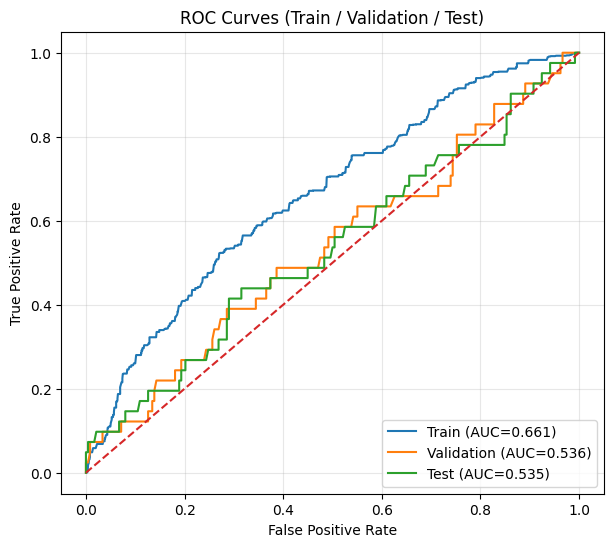


AUC with 95% Confidence Intervals
Train: 0.661 (95% CI: 0.638–0.682)
Validation: 0.536 (95% CI: 0.431–0.638)
Test: 0.535 (95% CI: 0.432–0.630)


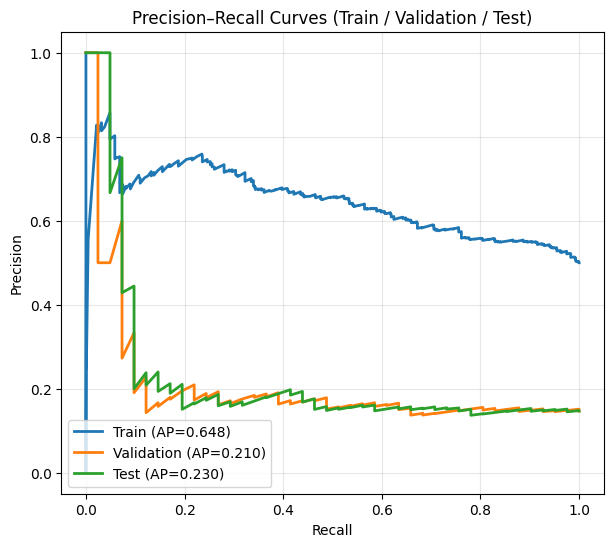

In [7]:
#1️⃣ Split data into Train / Validation / Test (70/15/15)
from sklearn.model_selection import train_test_split

# First split: Train + Temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: Validation + Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

#2️⃣ Apply SMOTE ONLY on training
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=2)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

#3️⃣ Feature scaling (fit on train only)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

#4️⃣ Train model (example: Logistic Regression)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_res, y_train_res)

#5️⃣ UNIVERSAL evaluation function (this is key )
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

def evaluate_model(name, model, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(y, y_pred),
        "Recall (Sensitivity)": recall_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "F1-score": f1_score(y, y_pred),
        "AUC-ROC": roc_auc_score(y, y_prob)
    }

    print(f"\n🔹 {name} Results")
    for k, v in metrics.items():
        print(f"{k}: {v:.3f}")

    return y_prob

#6️⃣ Evaluate Train / Validation / Test
# Training (on resampled data)
train_prob = evaluate_model(
    "Training",
    model,
    X_train_res,
    y_train_res
)

# Validation
val_prob = evaluate_model(
    "Validation",
    model,
    X_val,
    y_val
)

# Test
test_prob = evaluate_model(
    "Test",
    model,
    X_test,
    y_test
)

# ================================
# AUC with 95% Confidence Intervals
# ================================
from sklearn.metrics import roc_auc_score
import numpy as np

def auc_ci(y_true, y_prob, n_bootstraps=2000, alpha=0.95, seed=42):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    rng = np.random.RandomState(seed)
    scores = []

    for _ in range(n_bootstraps):
        idx = rng.randint(0, len(y_prob), len(y_prob))
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(roc_auc_score(y_true[idx], y_prob[idx]))

    lower = np.percentile(scores, (1 - alpha) / 2 * 100)
    upper = np.percentile(scores, (1 + alpha) / 2 * 100)

    return lower, upper


#7️⃣ ROC curves for Train / Val / Test (publication-ready)
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc(y, prob, label):
    fpr, tpr, _ = roc_curve(y, prob)
    return fpr, tpr, auc(fpr, tpr)

fpr_tr, tpr_tr, auc_tr = plot_roc(y_train_res, train_prob, "Train")
fpr_val, tpr_val, auc_val = plot_roc(y_val, val_prob, "Validation")
fpr_te, tpr_te, auc_te = plot_roc(y_test, test_prob, "Test")

plt.figure(figsize=(7,6))
plt.plot(fpr_tr, tpr_tr, label=f"Train (AUC={auc_tr:.3f})")
plt.plot(fpr_val, tpr_val, label=f"Validation (AUC={auc_val:.3f})")
plt.plot(fpr_te, tpr_te, label=f"Test (AUC={auc_te:.3f})")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Train / Validation / Test)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.savefig("roc_train_val_test.png", dpi=300, bbox_inches="tight")
plt.show()

# Compute CI
ci_train = auc_ci(y_train_res, train_prob)
ci_val = auc_ci(y_val, val_prob)
ci_test = auc_ci(y_test, test_prob)

print("\nAUC with 95% Confidence Intervals")
print(f"Train: {auc_tr:.3f} (95% CI: {ci_train[0]:.3f}–{ci_train[1]:.3f})")
print(f"Validation: {auc_val:.3f} (95% CI: {ci_val[0]:.3f}–{ci_val[1]:.3f})")
print(f"Test: {auc_te:.3f} (95% CI: {ci_test[0]:.3f}–{ci_test[1]:.3f})")

# ================================
# Precision–Recall Curves
# ================================
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_pr(y, prob, label):
    precision, recall, _ = precision_recall_curve(y, prob)
    ap = average_precision_score(y, prob)
    plt.plot(recall, precision, linewidth=2,
             label=f"{label} (AP={ap:.3f})")

plt.figure(figsize=(7,6))

plot_pr(y_train_res, train_prob, "Train")
plot_pr(y_val, val_prob, "Validation")
plot_pr(y_test, test_prob, "Test")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves (Train / Validation / Test)")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)

plt.savefig("precision_recall_train_val_test.png", dpi=300, bbox_inches="tight")
plt.show()


In [9]:
####cross validation without birad
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scoring = {
    'accuracy': 'accuracy',
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Features WITHOUT BIRADS
X_no_birads = data.drop(columns=['target', 'BIRADS category'])
y = data['target']

pipeline_no_birads = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000))
])

cv_results_no_birads = cross_validate(
    pipeline_no_birads,
    X_no_birads,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print("\n📌 CROSS-VALIDATION RESULTS (WITHOUT BIRADS)")
for metric in scoring.keys():
    mean = cv_results_no_birads[f'test_{metric}'].mean()
    std = cv_results_no_birads[f'test_{metric}'].std()
    print(f"{metric.upper():10s}: {mean:.3f} ± {std:.3f}")



📌 CROSS-VALIDATION RESULTS (WITHOUT BIRADS)
ACCURACY  : 0.573 ± 0.029
RECALL    : 0.577 ± 0.026
PRECISION : 0.189 ± 0.011
F1        : 0.284 ± 0.013
ROC_AUC   : 0.602 ± 0.014


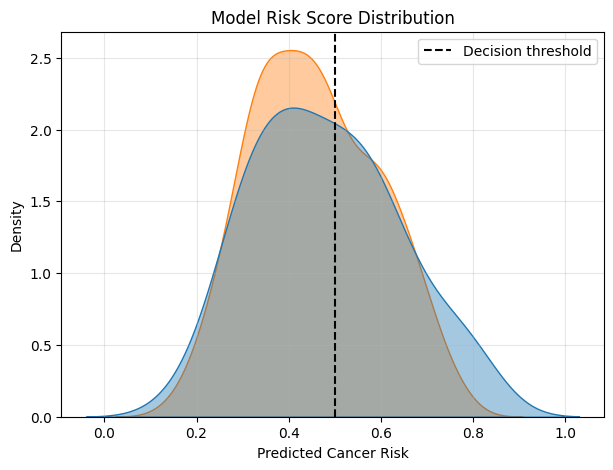

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = pd.DataFrame({
    "Risk score": test_prob,
    "Actual label": y_test.map({0: "Not Cancer", 1: "Cancer"})
})

plt.figure(figsize=(7,5))
sns.kdeplot(
    data=df_plot,
    x="Risk score",
    hue="Actual label",
    fill=True,
    common_norm=False,
    alpha=0.4
)

plt.axvline(0.5, color="black", linestyle="--", label="Decision threshold")
plt.title("Model Risk Score Distribution")
plt.xlabel("Predicted Cancer Risk")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

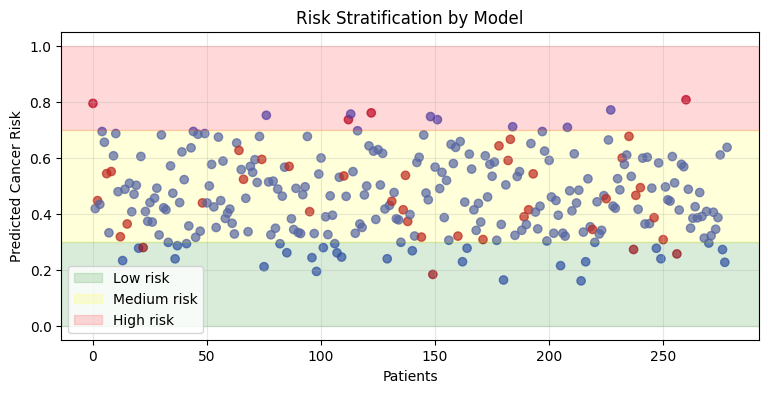

In [11]:
plt.figure(figsize=(9,4))
plt.scatter(
    range(len(test_prob)),
    test_prob,
    c=y_test,
    cmap="coolwarm",
    alpha=0.7
)

plt.axhspan(0, 0.3, color="green", alpha=0.15, label="Low risk")
plt.axhspan(0.3, 0.7, color="yellow", alpha=0.15, label="Medium risk")
plt.axhspan(0.7, 1.0, color="red", alpha=0.15, label="High risk")

plt.xlabel("Patients")
plt.ylabel("Predicted Cancer Risk")
plt.title("Risk Stratification by Model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [12]:
#we use the same data model so the output we get is same 
from PIL import Image
import numpy as np

def load_single_image(img_path, img_size=(224, 224)):
    img = Image.open(img_path).convert("RGB")
    img = img.resize(img_size)
    img = np.array(img).astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)  # (1, H, W, C)
    return img

def load_clinical_without_birads(age, density):
    return np.array([[age, density]], dtype="float32")

img_path = "/media/kirti/HD/PROJECT/codebook/trial.tif"
Ximg = load_single_image(img_path)   # shape: (1, H, W, C)

# WITHOUT BIRADS
Xclin_without = load_clinical_without_birads(age=44, density=3)
prob_without = model_without.predict([Ximg, Xclin_without])[0][0]

print(f"WITHOUT BIRADS Probability: {prob_without:.3f}")

heatmap_without = grad_cam_hybrid(
    model_without,
    Ximg,
    Xclin_without,
    layer_name="top_conv"
)

plt.figure(figsize=(12,5))

# WITHOUT BIRADS
plt.subplot(1,2,1)
overlay_heatmap(Ximg[0], heatmap_without, cmap="jet")
plt.title(f"WITHOUT BIRADS\nProb = {prob_without:.3f}")
plt.axis("off")

plt.suptitle("Grad-CAM Comparison: Effect of BIRADS", fontsize=14)
plt.show()


NameError: name 'model_without' is not defined

In [27]:
import os
print(os.getcwd())

/media/kirti/HD/PROJECT/codebook


In [28]:
pip install grad-cam

Note: you may need to restart the kernel to use updated packages.


In [3]:
import torch
from torchvision import models
import torch.nn as nn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=None)
model.fc = nn.Linear(2048, 2)

checkpoint = torch.load("resnet50_full_upgrade_best.pth", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [4]:
from PIL import Image
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

def load_image(path):
    img = Image.open(path).convert("RGB")
    img = transform(img).unsqueeze(0)
    return img.to(DEVICE)

img_path = "/media/kirti/HD/PROJECT/codebook/trial.tif"
input_tensor = load_image(img_path)


In [5]:
import torch.nn.functional as F

with torch.no_grad():
    logits = model(input_tensor)
    probs = F.softmax(logits, dim=1)

cancer_prob = probs[0, 0].item()  # assuming index 0 = cancer
print(f"Cancer probability: {cancer_prob:.3f}")


Cancer probability: 0.995


In [6]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt

target_layer = model.layer4[-1]  # LAST conv block of ResNet50

cam = GradCAM(
    model=model,
    target_layers=[target_layer]
)

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=None
)[0]


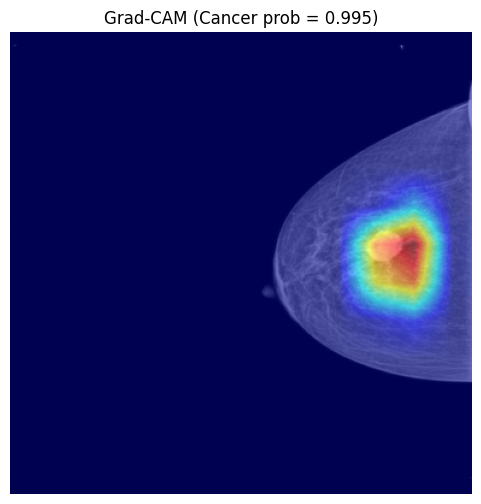

In [7]:
# Convert tensor back to image
img_np = input_tensor[0].permute(1, 2, 0).cpu().numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

cam_image = show_cam_on_image(
    img_np,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(6,6))
plt.imshow(cam_image)
plt.title(f"Grad-CAM (Cancer prob = {cancer_prob:.3f})")
plt.axis("off")
plt.show()


In [1]:
#without birad category WITHOUT BIRAD
# ----------------------------------------
# Step 1: Import Required Libraries
# ----------------------------------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------------------
# Step 2: Load the Dataset
# ----------------------------------------
data = pd.read_csv('details.csv')

# ----------------------------------------
# Step 3: Keep Only Cancer and Not Cancer Labels
# ----------------------------------------
data = data[data['Ground truth label'].isin(['Cancer', 'Not cancer'])]
data['target'] = data['Ground truth label'].map({'Cancer': 1, 'Not cancer': 0})

# ----------------------------------------
# Step 4: Drop Unnecessary or Leaky Columns
# ----------------------------------------
drop_cols = [
    'Sample Type ID', 'Sample ID', 'De-identified Patient ID',
    'Ground truth label', 'Clinical Indication',
    'ICD-11 Code (patient health condition)'
]
data.drop(columns=drop_cols, inplace=True, errors='ignore')

# ----------------------------------------
# Step 5: Handle Missing Values and Remove Duplicates
# ----------------------------------------
data = data.drop_duplicates()
data.ffill(inplace=True)  # forward-fill missing values safely

# ----------------------------------------
# Step 6: Encode Categorical Columns
# ----------------------------------------
for col in data.select_dtypes(include='object').columns:
    data[col] = LabelEncoder().fit_transform(data[col])

# ----------------------------------------
# Step 7: Split Features (X) and Target (y)
# ----------------------------------------
X = data.drop(columns=['target', 'BIRADS category'])
#X = data.drop(columns=['target'])
y = data['target']

# Optional: Remove BIRADS if you want more general model
# X = X.drop(columns=['BIRADS category'])

# ----------------------------------------
# Step 8: Train-Test Split (80/20)
# ----------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ----------------------------------------
# Step 9: Balance Classes Using SMOTE
# ----------------------------------------
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# ----------------------------------------
# Step 10: Feature Scaling
# ----------------------------------------
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)

# ----------------------------------------
# Step 11: Model 1 – Logistic Regression
# ----------------------------------------
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_res, y_train_res)
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

print("\n🔹 Logistic Regression:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 3))
print("Sensitivity (Recall):", round(recall_score(y_test, y_pred_lr), 3))
print("AUC-ROC:", round(roc_auc_score(y_test, y_prob_lr), 3))

# ----------------------------------------
# Step 12: Model 2 – Neural Network (MLP)
# ----------------------------------------
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=500, random_state=42)
mlp.fit(X_train_res, y_train_res)
y_pred_mlp = mlp.predict(X_test)
y_prob_mlp = mlp.predict_proba(X_test)[:, 1]

print("\n🔹 Neural Network (MLP):")
print("Accuracy:", round(accuracy_score(y_test, y_pred_mlp), 3))
print("Sensitivity (Recall):", round(recall_score(y_test, y_pred_mlp), 3))
print("AUC-ROC:", round(roc_auc_score(y_test, y_prob_mlp), 3))

# ----------------------------------------
# Step 13: Confusion Matrix Visualization
# ----------------------------------------
cm = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (MLP)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Save confusion matrix
plt.savefig("confusion_matrix_mlp.png", dpi=300, bbox_inches='tight')
plt.close()
print("✔ Confusion matrix saved as confusion_matrix_mlp.png")


import matplotlib.pyplot as plt
importance = pd.Series(abs(log_reg.coef_[0]), index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance (Without BIRADS)")

# Save feature importance plot
plt.savefig("feature_importance_without_birads.png", dpi=300, bbox_inches='tight')
plt.close()
print("✔ Feature importance saved as feature_importance_with_birads.png")


🔹 Logistic Regression:
Accuracy: 0.599
Sensitivity (Recall): 0.481
AUC-ROC: 0.564

🔹 Neural Network (MLP):
Accuracy: 0.632
Sensitivity (Recall): 0.389
AUC-ROC: 0.543
✔ Confusion matrix saved as confusion_matrix_mlp.png
✔ Feature importance saved as feature_importance_with_birads.png


In [2]:
# First split Test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Split remaining into Train (70%) and Validation (10%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)


In [3]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


In [4]:
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


In [5]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_res, y_train_res)

# Predicted probabilities
y_prob_train = log_reg.predict_proba(X_train_res)[:, 1]
y_prob_val = log_reg.predict_proba(X_val)[:, 1]
y_prob_test = log_reg.predict_proba(X_test)[:, 1]


In [6]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr
import numpy as np

def regression_metrics(y_true, y_prob, dataset_name):
    mse = mean_squared_error(y_true, y_prob)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_prob)
    r2 = r2_score(y_true, y_prob)
    pearson_r, pval = pearsonr(y_true, y_prob)

    print(f"\n🔹 {dataset_name}")
    print("RMSE:", round(rmse, 3))
    print("MSE:", round(mse, 3))
    print("R2:", round(r2, 3))
    print("MAE:", round(mae, 3))
    print("Pearson R:", round(pearson_r, 3))
    print("P-value:", "{:.2e}".format(pval))

# Calculate for all sets
regression_metrics(y_train_res, y_prob_train, "Train")
regression_metrics(y_val, y_prob_val, "Validation")
regression_metrics(y_test, y_prob_test, "Test")



🔹 Train
RMSE: 0.467
MSE: 0.218
R2: 0.127
MAE: 0.437
Pearson R: 0.357
P-value: 1.29e-67

🔹 Validation
RMSE: 0.473
MSE: 0.224
R2: -0.805
MAE: 0.442
Pearson R: 0.07
P-value: 3.39e-01

🔹 Test
RMSE: 0.478
MSE: 0.228
R2: -0.84
MAE: 0.448
Pearson R: 0.08
P-value: 1.25e-01


In [7]:
# rasnet 50 for the regression 
import torch
import torch.nn.functional as F
import numpy as np
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr
import os


In [8]:
DATA_DIR = "final_dataset"
MODEL_PATH = "resnet50_full_upgrade_best.pth"
BATCH_SIZE = 8
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)


Device: cpu


In [9]:
val_transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])


In [10]:
train_data = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=val_transform)
val_data   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), transform=val_transform)
test_data  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=val_transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

num_classes = len(train_data.classes)


In [11]:
model = models.resnet50(weights=None)
in_features = model.fc.in_features
model.fc = torch.nn.Linear(in_features, num_classes)

checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully")


Model loaded successfully


In [12]:
def evaluate_regression(loader, dataset_name):
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            probs = F.softmax(outputs, dim=1)[:, 1]

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    y_true = np.array(all_labels)
    y_prob = np.array(all_probs)

    mse = mean_squared_error(y_true, y_prob)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_prob)
    r2 = r2_score(y_true, y_prob)
    pearson_r, pval = pearsonr(y_true, y_prob)

    print(f"\n🔹 {dataset_name}")
    print("RMSE:", round(rmse, 3))
    print("MSE:", round(mse, 3))
    print("R2:", round(r2, 3))
    print("MAE:", round(mae, 3))
    print("Pearson R:", round(pearson_r, 3))
    print("P-value:", "{:.2e}".format(pval))


In [13]:
evaluate_regression(train_loader, "Train")
evaluate_regression(val_loader, "Validation")
evaluate_regression(test_loader, "Test")



🔹 Train
RMSE: 0.069
MSE: 0.005
R2: 0.939
MAE: 0.011
Pearson R: 0.971
P-value: 0.00e+00

🔹 Validation
RMSE: 0.161
MSE: 0.026
R2: 0.662
MAE: 0.038
Pearson R: 0.817
P-value: 1.47e-129

🔹 Test
RMSE: 0.146
MSE: 0.021
R2: 0.719
MAE: 0.036
Pearson R: 0.849
P-value: 1.45e-151
